# Method validation - simulations 
- pure noise
- signal with known dim

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import skdim
from sklearn.decomposition import PCA
import tphate 
import plotting_helpers as helpers
import os, sys
sys.path.append('..')
from RepBiomrkr import simulate_correlated_data as scd 
# Add the text to allow plots to be saved in pdf format with text edit
%load_ext autoreload
%autoreload 2
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
my_colormap = [ "#fb7fc3","#f6b663", "#e0f663","#8ad878","#a0c9f0", "#af6adc" ]
seed=4
RERUN=0


# helper functions

In [ ]:
def compute_tphate_ide(X, threshold=0.9, knn=5, mod_ac=0):
    tph=tphate.TPHATE(verbose=0, knn=knn)
    tph.fit(X)
    if tph.dropoff == 1 and mod_ac>0:
        tph=tphate.TPHATE(verbose=0, knn=knn, smooth_window=mod_ac)
        tph.fit(X)
        print(f'AC is now {tph.dropoff}; continuing')
    D=tph.diff_op
    return diffop_eig_ide(D, threshold)

def diffop_eig_ide(X, threshold=0.9):
    eigenvalues, _ = np.linalg.eig(X)
    sorted_eigenvalues = np.real(np.sort(eigenvalues)[::-1]) 
    explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)
    n = np.where(cumulative_variance>threshold)[0][0]+1
    return n

def compute_pca_ide(X, threshold=0.9):
    pca = PCA()
    pca.fit(X)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n = np.where(cumulative_variance>threshold)[0][0]+1
    return n

# benchmark manifold datasets

In [2]:
bnchmk = skdim.datasets.BenchmarkManifolds(random_state=seed)
benchmark_datasets = bnchmk.generate(n=200, noise=0)
shapes=benchmark_datasets.keys()
shapes = ['M5a_Helix1d', 'M6_Nonlinear', 'M7_Roll', 'M13b_Spiral', "Mp1_Paraboloid"]
bnchmk.truth.loc[shapes]

,Intrinsic Dimension,Number of variables,Description
M5a_Helix1d,1,3,1D helix
M6_Nonlinear,6,36,Nonlinear manifold
M7_Roll,2,3,Swiss Roll
M13b_Spiral,1,13,1D helix curve
Mp1_Paraboloid,3,12,"3D paraboloid, nonlinearly embedded in (3(3+1)..."


In [4]:
def add_autocorrelated_noise(data, sigma, alpha=0.5, seed=None):
    """
    Add temporally autocorrelated noise to a dataset.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input dataset of shape (n_samples, n_features)
    sigma : float
        Standard deviation of the noise
    alpha : float, optional (default=0.5)
        Autocorrelation coefficient (0 <= alpha < 1)
        Higher values create stronger temporal correlation
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    noisy_data : numpy.ndarray
        Dataset with added autocorrelated noise
    """
    if seed is not None:
        np.random.seed(seed)
    
    noisy_data = np.zeros_like(data)
    # Initialize first sample with uncorrelated noise
    prev_noise = np.random.normal(0.0, sigma, size=data.shape[1])
    noisy_data[0] = data[0] + prev_noise
    corrs=[]
    # Add autocorrelated noise to subsequent samples
    for t in range(1, data.shape[0]):
        # add noise correlated with previous noise
        new_noise = alpha * prev_noise + np.random.normal(0.0, sigma , size=data.shape[1])
        noisy_data[t] = data[t] + new_noise
        prev_noise = new_noise
        corrs.append(np.corrcoef(noisy_data[t], noisy_data[t-1])[0,1])
    return noisy_data

In [5]:
RERUN = 0 
if RERUN or not os.path.exists('compiled/results/benchmark_id_results_autocorrelated_noise.csv'):
    print('Running benchmark with autocorrelated noise...')
    results = pd.DataFrame(columns=['dataset', 'intrinsic_dimension','embedding_dimensions' , 'IDE', 'noise', 'ID_error', 'method', 'iteration', 'normalized_error'])
    for noise in np.arange(0,1.1,0.1):
        # Generate temporally structured noise with given noise level
        noise=np.round(noise,2)
        for name in shapes:
            print(f'Processing shape: {name} with noise level: {noise}')
            data = benchmark_datasets[name]
            if noise > 0: data = add_autocorrelated_noise(data, sigma=noise, alpha=0.05, seed=seed)
            id = bnchmk.truth.loc[name]['Intrinsic Dimension']
            ed = bnchmk.truth.loc[name]['Number of variables']
            n_tphate = compute_tphate_ide(data, threshold=0.9, knn=20, mod_ac=4)
            mle = skdim.id.MLE().fit(data).dimension_
            mind = skdim.id.MiND_ML().fit(data).dimension_
            lpca = skdim.id.lPCA(ver='participation_ratio').fit_transform(data)
            danc = skdim.id.DANCo().fit(data).dimension_
            n_pca=compute_pca_ide(data, threshold=0.9)
            for method, n_est in zip(['MLE', 'MiND_ML', 'lPCA', 'DANCo','TPHATE','PCA'], [mle, mind, lpca, danc,n_tphate,n_pca]):
                norm_err = abs(n_est - id)/ed
                results.loc[len(results)] = [name, id, ed, n_est, noise, n_est-id, method, seed, norm_err]
    results.to_csv('compiled/results/benchmark_id_results_autocorrelated_noise.csv', index=False)
results=pd.read_csv('compiled/results/benchmark_id_results_autocorrelated_noise.csv')

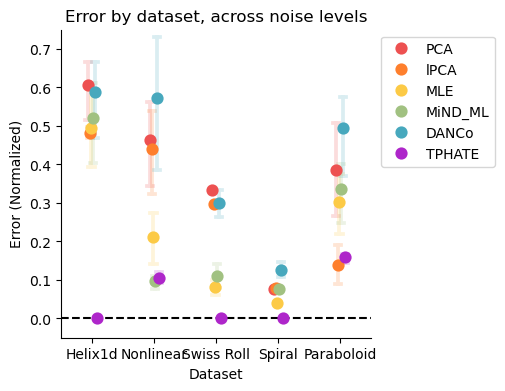

In [6]:
fig,ax=plt.subplots(1,1, figsize=(4,4))
order=['PCA','lPCA','MLE','MiND_ML','DANCo','TPHATE']
g=sns.pointplot(ax=ax,data=results, x='dataset', y='normalized_error', hue='method', 
                palette=helpers.get_palette7_rainbow(), ci=95, order=shapes, capsize=.1, hue_order=order, join=False, 
                dodge=True, 
                   errorbar=('ci', 95), err_kws={'alpha': 0.2, 'zorder': 1}, )
g.set( ylim=(-0.05,0.75),xlabel='Dataset', xticklabels=['Helix1d', 'Nonlinear', 'Swiss Roll', 'Spiral', 'Paraboloid'],
      ylabel='Error (Normalized)', title='Error by dataset, across noise levels')
# Move legend outside the plot
plt.axhline(0, ls='--', color='k', zorder=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.savefig('compiled/main_plots/ide_methods_comparison_by_dataset.pdf', bbox_inches='tight', format='pdf', transparent=True)

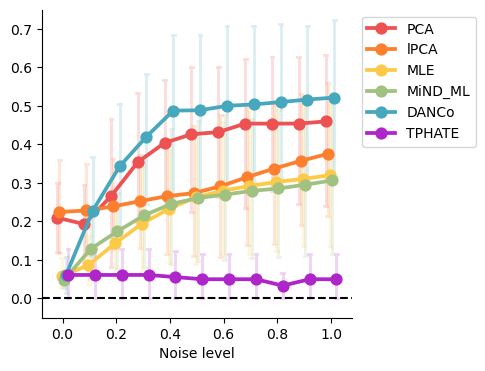

In [7]:
order=['PCA','lPCA','MLE','MiND_ML','DANCo','TPHATE']
fig,ax=plt.subplots(1,1, figsize=(4,4))
g=sns.pointplot(ax=ax,data=results, x='noise', y='normalized_error', hue='method',native_scale=True,ci=95,
                 palette=helpers.get_palette7_rainbow(),  errwidth=2, dodge=0.4, hue_order=order,capsize=.1, 
                   errorbar=('ci', 95), err_kws={'alpha': 0.2, 'zorder': 1}, )
g.set( ylim=(-0.05,0.75), xlabel='Noise level', ylabel='', title='')
# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.01,1), loc='upper left')
plt.axhline(0, ls='--', color='k')
sns.despine()

plt.savefig('compiled/main_plots/ide_methods_comparison_by_noise.pdf', bbox_inches='tight', format='pdf', transparent=True)

# simulated dataset with latent correlations
simulating noisy fMRI datasets with a known within-dataset (across features) and between-dataset correlation structure using functions from the repbiomrkr package. purposefully simulating minimal within-dataset correlation so that ID ~ ED

In [ ]:
nd = 10 # 10 participant
ns = 200 # samples
nf = 100 # measured features (embedding dimensions)
nl = 100 # latent features (intrinsic dimensions)
noise=1
within_corr = 0.0001 # correlation between features within a dataset
between_corr = 0.001 # correlation between datasets (n/a for 1 dataset)

filename = 'compiled/info/simulated_datasets.npy'
if RERUN == 0 and os.path.exists(filename):
    dss = np.load(filename, allow_pickle=True)
    print(f'loading simulated datasets shape {np.shape(dss)} from file')
else:
    simulator = scd.SimulatedCorrelatedData(n_datasets=nd, n_samples=ns, 
                                            n_features_measured=nf, n_features_latent=nl, 
                                            noise_sigma=noise, intra_ds_corr=within_corr, 
                                            inter_ds_corr=between_corr, verbose=1, seed=44)
    dss = simulator.generate()

    np.save(filename, np.array(dss))
    print(f'Saved simulated datasets {np.shape(dss)} to {filename}')

loading simulated datasets shape (10, 200, 100) from file


In [ ]:
simulator = scd.SimulatedCorrelatedData(n_datasets=nd, n_samples=ns, 
                                            n_features_measured=nf, n_features_latent=nl, 
                                            noise_sigma=noise, intra_ds_corr=within_corr, 
                                            inter_ds_corr=between_corr, verbose=1, seed=44)
_,c = simulator._compute_average_intra_dataset_correlations(dss)
stats.ttest_1samp(c, 0, alternative='greater') # sanity check that the simulated datasets are not significantly positively correalted within-dataset

TtestResult(statistic=-0.3495904636674842, pvalue=0.6326565596497233, df=9)

In [ ]:
sim_results=pd.DataFrame(columns=['dataset_idx', 'latent_signals','ide' , 'method'])
for i in range(len(dss)):
    print(f'Dataset {i}')
    sim_results.loc[len(sim_results)] = [i, nl, nl, 'Ground Truth']
    sim_results.loc[len(sim_results)] = [i, nl, compute_tphate_ide(dss[i]), 'T-PHATE']
    sim_results.loc[len(sim_results)] = [i, nl, compute_pca_ide(dss[i]), 'PCA']
    sim_results.loc[len(sim_results)] = [i, nl, skdim.id.MiND_ML().fit(dss[i]).dimension_, 'MiND_ML']
    sim_results.loc[len(sim_results)] = [i, nl, skdim.id.lPCA(ver='participation_ratio').fit_transform(dss[i]), 'lPCA']
    sim_results.loc[len(sim_results)] = [i, nl, skdim.id.DANCo().fit(dss[i]).dimension_, 'DANCo']
    sim_results.loc[len(sim_results)] = [i, nl, skdim.id.MLE().fit(dss[i]).dimension_, 'MLE']
sim_results.to_csv('compiled/info/simulated_correlated_datasets_ide_results.csv', index=False)
print('Finished computing IDE for simulated datasets')


Dataset 0
Dataset 1
Dataset 2
Dataset 3
Dataset 4
Dataset 5
Dataset 6
Dataset 7
Dataset 8
Dataset 9
Finished computing IDE for simulated datasets


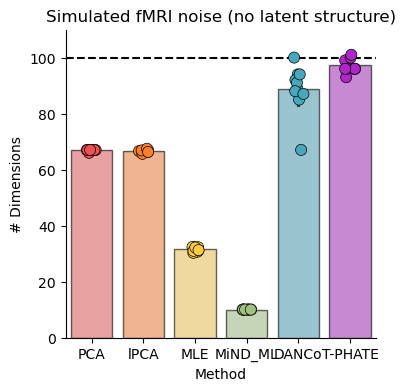

In [33]:
fig,ax=plt.subplots(1,1, figsize=(4,4))
order = ['PCA','lPCA','MLE','MiND_ML','DANCo','T-PHATE']
g=sns.barplot(data=sim_results, x='method', y='ide', order=order, 
            palette=helpers.get_palette7_rainbow(), edgecolor='k', 
            linewidth=1, alpha=0.6)
plt.axhline(nl, ls='--', color='k', label='# Signals')
g.set( ylim=(0,110), xlabel='Method', ylabel='# Dimensions', 
      title='Simulated fMRI noise (no latent structure)')
sns.stripplot(data=sim_results, x='method', y='ide',
              order=order, palette=helpers.get_palette7_rainbow(), 
              size=8, jitter=True, alpha=1, edgecolor='k', 
              linewidth=0.5)
sns.despine()
plt.savefig('compiled/main_plots/ide_methods_comparison_simulated_correlated_noise.pdf', 
            bbox_inches='tight', format='pdf', transparent=True)